Imports and setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from MuyGPyS._test.sampler import UnivariateSampler2D
from MuyGPyS.gp import MuyGPS
from MuyGPyS.gp.deformation import Isotropy, l2, F2
from MuyGPyS.gp.hyperparameter import AnalyticScale, Parameter
from MuyGPyS.gp.kernels import Matern, RBF
from MuyGPyS.gp.noise import HomoscedasticNoise
from MuyGPyS.neighbors import NN_Wrapper
from MuyGPyS.optimize.batch import sample_batch

In [2]:
points_per_dim = 60
train_ratio = 0.2

In [3]:
kernel = Matern(
    smoothness=Parameter(1.5),
    deformation=Isotropy(
        l2,
        length_scale=Parameter(0.2),
    ),
)

In [4]:
sampler = UnivariateSampler2D(
    points_per_dim=points_per_dim,
    train_ratio=train_ratio,
    kernel=kernel,
    noise=HomoscedasticNoise(1e-7),
    measurement_noise=HomoscedasticNoise(1e-14),
)

In [5]:
train_features, test_features = sampler.features()
train_count, _ = train_features.shape
test_count, _ = test_features.shape

In [6]:
train_responses, test_responses = sampler.sample()

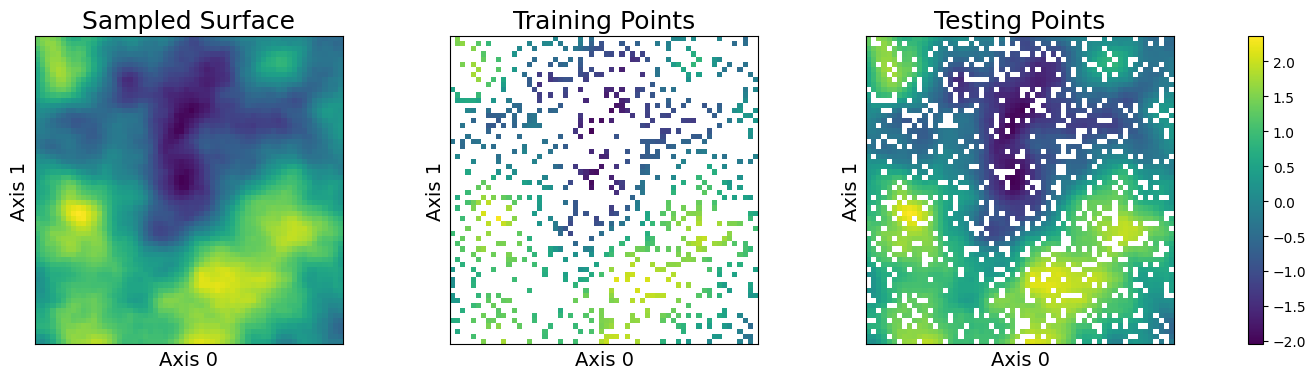

In [7]:
sampler.plot_sample()